# 009 Regime Analysis

Цель: проверить стабильность imbalance-сигнала в режимах рынка.

Режимы:
- low volatility vs high volatility (по median rolling vol)
- (опционально) day vs night: можно расширить позже

Структура:
1. Load data
2. Compute feature
3. Build target (200ms)
4. Basic statistics
5. Distribution plots
6. Relationship to future price (binning)
7. Time series (downsampled)
8. Correlation analysis
9. Extreme events analysis


In [1]:
# 1. Load data
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = None
for p in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (p / "pyproject.toml").exists() and (p / "research").is_dir():
        sys.path.insert(0, str(p))
        root = p
        break

root = root or Path.cwd()
data_dir = root / "data" / "reconstructed"

In [2]:
parquet_path = data_dir / "BTC-USDT-SWAP" / "grid100ms" / "2026-03-04" / (
    "book_grid100ms_BTC-USDT-SWAP_2026-03-04_10-00-00__2026-03-04_11-00-00.parquet"
)
if not parquet_path.exists():
    found = sorted(data_dir.rglob("*.parquet"))
    parquet_path = found[0] if found else parquet_path
    if found:
        print("Default parquet not found, loading:", parquet_path)

df = pd.read_parquet(parquet_path)
df.head()

,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,...,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-04 10:00:00+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.9,0.02
1,2026-03-04 10:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.71,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.4,0.70
2,2026-03-04 10:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,333.47,71492.3,0.01,...,71494.9,0.73,71495.0,0.01,71495.3,0.70,71496.0,0.78,71496.2,0.70
3,2026-03-04 10:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,337.18,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71495.5,0.70,71496.0,0.08,71496.3,0.03
4,2026-03-04 10:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,353.48,71492.3,0.01,...,71495.0,0.01,71496.0,0.02,71496.9,0.02,71497.0,8.73,71497.3,0.30


In [3]:
# 1 hour slice
_df = df.copy()
_df["ts_event"] = pd.to_datetime(_df["ts_event"], utc=True)
_df = _df.sort_values("ts_event").reset_index(drop=True)
start_ts = _df["ts_event"].min()
end_ts = start_ts + pd.Timedelta(hours=1)
_df = _df[_df["ts_event"].between(start_ts, end_ts)].reset_index(drop=True)
print("Rows:", len(_df))
print("Range:", _df["ts_event"].min(), "..", _df["ts_event"].max())

Rows: 36001
Range: 2026-03-04 10:00:00+00:00 .. 2026-03-04 11:00:00+00:00


In [4]:
# 2. Compute feature: imbalance + volatility regime
_df["mid_price"] = (_df["bid_px_01"] + _df["ask_px_01"]) / 2
_denom = (_df["bid_sz_01"] + _df["ask_sz_01"]).replace(0, np.nan)
_df["imbalance_l1"] = ((_df["bid_sz_01"] - _df["ask_sz_01"]) / _denom).fillna(0)

# volatility proxy (1s rolling std of mid diff)
_df["mid_diff"] = _df["mid_price"].diff()
_df["vol_1s"] = _df["mid_diff"].rolling(10).std().fillna(0)

vol_median = _df["vol_1s"].median()
_df["regime_vol"] = np.where(_df["vol_1s"] > vol_median, "high_vol", "low_vol")

_df[["ts_event", "imbalance_l1", "vol_1s", "regime_vol"]].head()

,ts_event,imbalance_l1,vol_1s,regime_vol
0,2026-03-04 10:00:00+00:00,0.510785,0.0,low_vol
1,2026-03-04 10:00:00.100000+00:00,0.510785,0.0,low_vol
2,2026-03-04 10:00:00.200000+00:00,0.212662,0.0,low_vol
3,2026-03-04 10:00:00.300000+00:00,0.219480,0.0,low_vol
4,2026-03-04 10:00:00.400000+00:00,0.954116,0.0,low_vol


In [5]:
# 3. Target: 200ms future mid
_df["future_mid"] = _df["mid_price"].shift(-2)
_df["delta"] = _df["future_mid"] - _df["mid_price"]
_df["target"] = np.sign(_df["delta"]).astype("Int64")

_df2 = _df.dropna(subset=["future_mid"]).reset_index(drop=True)
print("Rows after shift:", len(_df2))

Rows after shift: 35999



Regime: high_vol | rows: 17998
imbalance_l1 mean: 0.02930679527257269
imbalance_l1 std: 0.6540734762718716
imbalance_l1 min/max: -0.9999886573732745 0.9999837500101563

Regime: low_vol | rows: 18001
imbalance_l1 mean: 0.055712273019893566
imbalance_l1 std: 0.6115153780858376
imbalance_l1 min/max: -0.9999468396151189 0.999977866802417


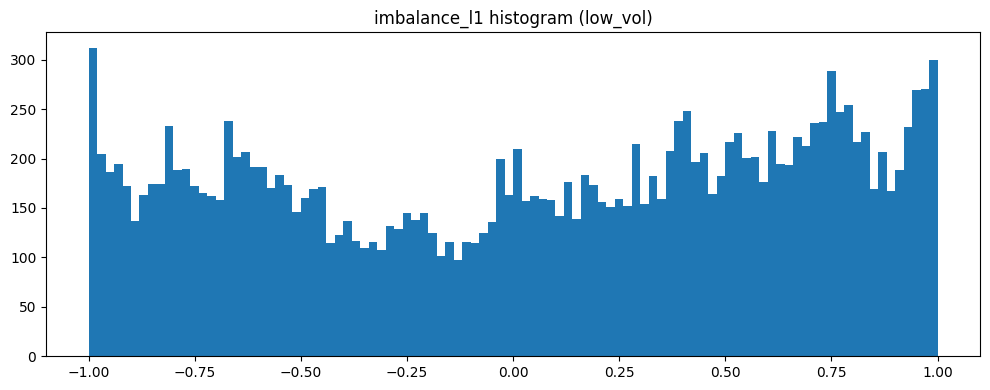

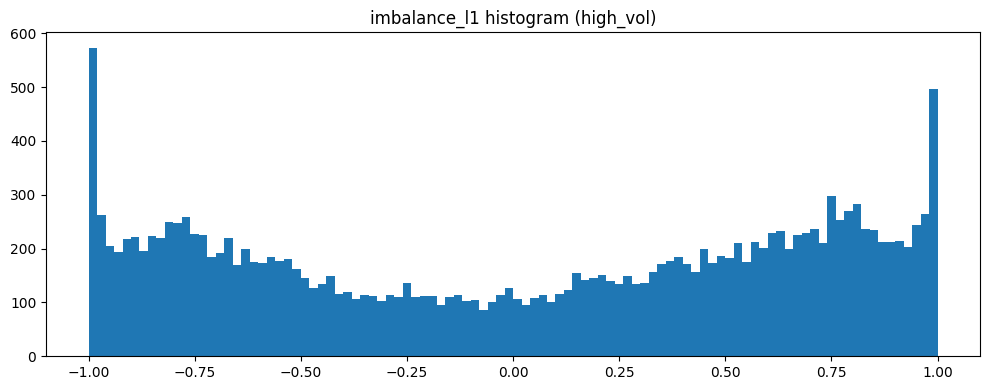

In [6]:
# 4. Basic statistics per regime
for regime, g in _df2.groupby("regime_vol"):
    s = g["imbalance_l1"]
    print(f"\nRegime: {regime} | rows: {len(g)}")
    print("imbalance_l1 mean:", s.mean())
    print("imbalance_l1 std:", s.std())
    print("imbalance_l1 min/max:", s.min(), s.max())

# 5. Distribution plots
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(_df2[_df2["regime_vol"] == "low_vol"]["imbalance_l1"].values, bins=100)
ax.set_title("imbalance_l1 histogram (low_vol)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(_df2[_df2["regime_vol"] == "high_vol"]["imbalance_l1"].values, bins=100)
ax.set_title("imbalance_l1 histogram (high_vol)")
plt.tight_layout()
plt.show()

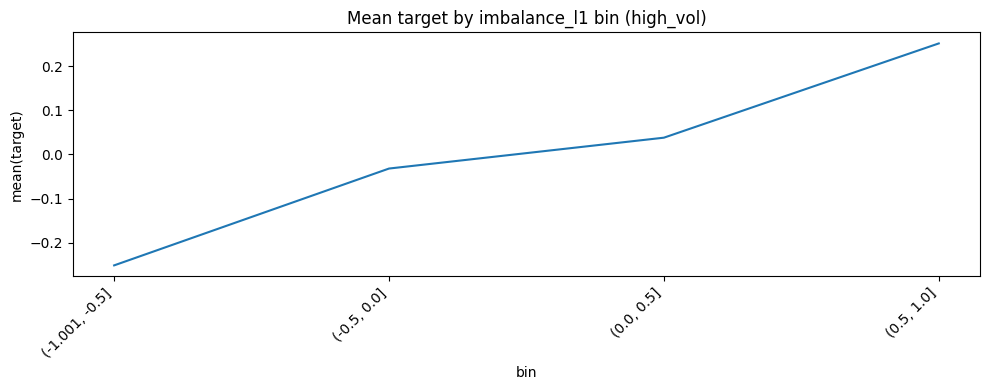

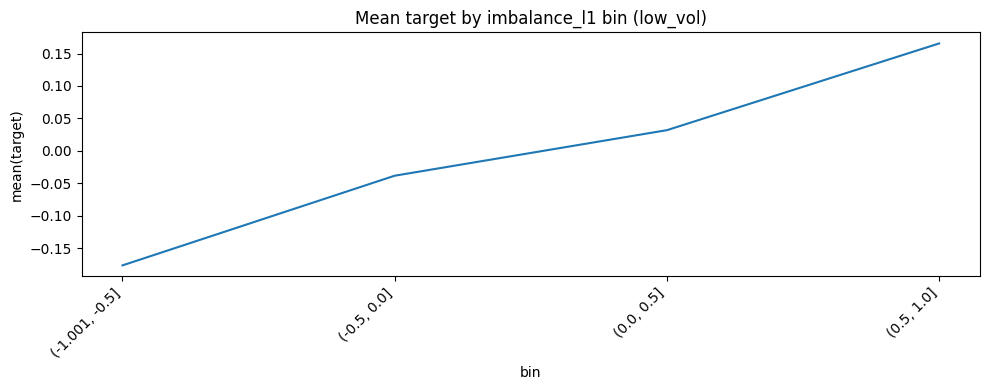

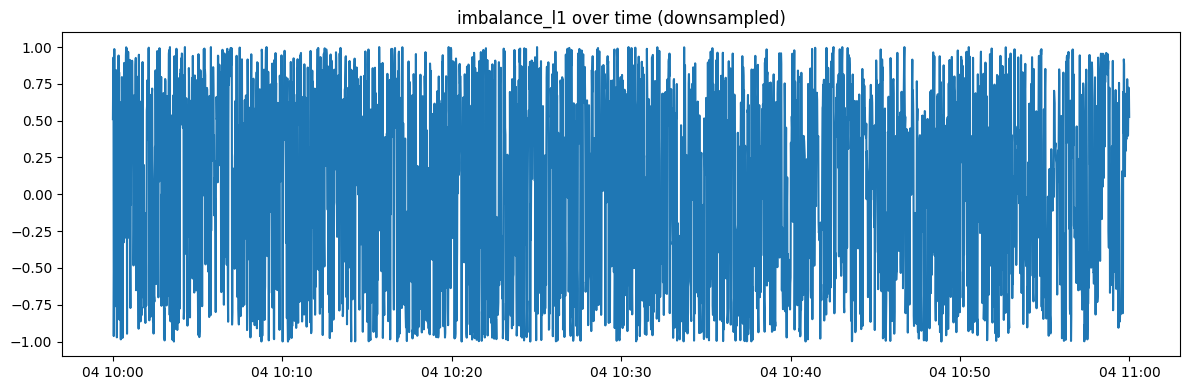

Correlation imbalance_l1 vs delta (high_vol): 0.2928272271133344
Correlation imbalance_l1 vs delta (low_vol): 0.24028052415952844

Extreme abs(imbalance_l1)>0.8 (high_vol)
count: 5159
avg delta: -0.028736189184071666
mean target: 0.006590424500872262

Extreme abs(imbalance_l1)>0.8 (low_vol)
count: 4196
avg delta: 0.029623450905562673
mean target: 0.009532888465204958


In [7]:
# 6. Relationship to future price (binning) per regime
bins = [-1.0, -0.5, 0.0, 0.5, 1.0]

for regime, g in _df2.groupby("regime_vol"):
    gg = g.copy()
    gg["bin"] = pd.cut(gg["imbalance_l1"], bins=bins, include_lowest=True)
    mean_target = gg.groupby("bin", observed=True)["target"].mean()

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(range(len(mean_target)), mean_target.values)
    ax.set_title(f"Mean target by imbalance_l1 bin ({regime})")
    ax.set_xlabel("bin")
    ax.set_ylabel("mean(target)")
    ax.set_xticks(range(len(mean_target)))
    ax.set_xticklabels([str(x) for x in mean_target.index], rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

# 7. Time series (downsample)
down = _df2.iloc[::10].copy()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(down["ts_event"], down["imbalance_l1"].values)
ax.set_title("imbalance_l1 over time (downsampled)")
plt.tight_layout()
plt.show()

# 8. Correlation analysis per regime
for regime, g in _df2.groupby("regime_vol"):
    print(f"Correlation imbalance_l1 vs delta ({regime}):", g["imbalance_l1"].corr(g["delta"]))

# 9. Extreme events analysis per regime
for regime, g in _df2.groupby("regime_vol"):
    ext = g[g["imbalance_l1"].abs() > 0.8]
    print(f"\nExtreme abs(imbalance_l1)>0.8 ({regime})")
    print("count:", len(ext))
    print("avg delta:", ext["delta"].mean())
    print("mean target:", ext["target"].mean())